# NetKet 中的 `expect_and_grad` 函数原理详解

本 notebook 将详细介绍 NetKet 库中 `expect_and_grad` 函数的工作原理，这是变分蒙特卡洛(VMC)方法的核心组件。

## 目录
1. [背景介绍](#背景介绍)
2. [expect_and_grad 函数概述](#expect_and_grad-函数概述)
3. [数学原理](#数学原理)
4. [实现细节](#实现细节)
5. [使用示例](#使用示例)
6. [性能优化](#性能优化)
7. [总结](#总结)

## 背景介绍

NetKet 是一个基于 JAX 构建的 Python 库，专门用于研究多体量子系统。它提供了高效的机器学习工具来近似量子态，并计算各种物理量。

在变分蒙特卡洛(VMC)方法中，我们需要计算两个核心量：
1. 期望值 $\langle O \rangle = \frac{\langle \psi|O|\psi\rangle}{\langle \psi|\psi\rangle}$
2. 能量对参数的梯度 $\nabla_\theta E$，用于优化变分参数

`expect_and_grad` 函数正是为了同时计算这两个量而设计的。

## expect_and_grad 函数概述

`expect_and_grad` 是 NetKet 中变分量子态(`vqs`)对象的一个方法，用于同时计算算符的期望值和能量对变分参数的梯度。

### 函数签名
```python
vstate.expect_and_grad(operator, *, use_covariance=None)
```

### 返回值
返回一个元组：(期望值, 梯度字典)
- 期望值：包含统计误差、方差等信息的统计量
- 梯度字典：与变分参数结构相同的字典，包含每个参数的梯度

## 数学原理

### 期望值计算
对于哈密顿量 $H$ 和变分波函数 $|\psi_\theta\rangle$，能量期望值为：
$$E(\theta) = \frac{\langle \psi_\theta|H|\psi_\theta\rangle}{\langle \psi_\theta|\psi_\theta\rangle}$$

在蒙特卡洛采样中，这转化为：
$$E(\theta) = \sum_i w_i E_L(\sigma_i)$$
其中 $E_L(\sigma_i) = \frac{H\psi(\sigma_i)}{\psi(\sigma_i)}$ 是局部能量，$w_i$ 是采样权重。

### 梯度计算

能量对参数 $\theta_k$ 的梯度为：
$$\frac{\partial E}{\partial \theta_k} = 2\text{Re}\left[ \langle O_k E_L \rangle - \langle O_k \rangle \langle E_L \rangle \right]$$

其中 $O_k = \frac{\partial \log \psi}{\partial \theta_k}$ 是对数波函数对参数的导数，也称为"对数导数"或"力"。

这种形式可以看作是局部能量与对数导数的协方差，因此也称为"协方差公式"。

### 参数化波函数

在 NetKet 中，波函数通常通过神经网络参数化：
$$\psi_\theta(\sigma) = \exp(f_\theta(\sigma))$$

其中 $f_\theta(\sigma)$ 是神经网络输出，$\theta$ 是可训练参数。这种参数化确保了波函数的归一化性质，并简化了梯度计算。

## 实现细节

### 采样过程

1. **初始化**：从初始随机配置开始
2. **马尔可夫链**：使用 Metropolis-Hastings 算法生成样本
   - 提议新配置 $\sigma' \to \sigma$
   - 计算接受概率 $A = \min\left(1, \left|\frac{\psi(\sigma')}{\psi(\sigma)}\right|^2\right)$
   - 根据概率接受或拒绝提议
3. **收集样本**：经过热身后，收集一系列配置用于计算

### 自动微分

NetKet 利用 JAX 的自动微分功能计算梯度：

1. **前向传播**：计算波函数值 $\psi_\theta(\sigma)$
2. **反向传播**：自动计算 $\frac{\partial \log \psi}{\partial \theta_k}$
3. **梯度聚合**：根据协方差公式计算能量梯度

### 统计误差估计

NetKet 提供了多种统计量来评估计算质量：

- **误差估计**：通过样本方差计算标准误差
- **方差**：$\text{Var}(E_L) = \langle E_L^2 \rangle - \langle E_L \rangle^2$
- **$\hat{R}$ 统计量**：评估马尔可夫链收敛性（接近1表示已收敛）
- **自相关时间**：衡量样本间的相关性

## 使用示例

下面我们通过一个简单的例子演示如何使用 `expect_and_grad` 函数。

In [1]:
# 安装 NetKet (如果需要)
# !pip install --quiet netket

import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"  # 使用 CPU

import netket as nk
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import nnx

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 定义一个简单的1D横场伊辛模型
N = 20  # 自旋数
hi = nk.hilbert.Spin(s=1/2, N=N)  # 定义希尔伯特空间

# 构建哈密顿量
Gamma = -1.0
H = sum([Gamma * nk.operator.spin.sigmax(hi, i) for i in range(N)])

V = -1.0
H += sum([V * nk.operator.spin.sigmaz(hi, i) @ nk.operator.spin.sigmaz(hi, (i + 1) % N) for i in range(N)])

In [3]:
# 定义一个简单的平均场模型
class MFModel(nnx.Module):
    def __init__(self, *, rngs: nnx.Rngs):
        # 定义一个可训练参数
        self.log_phi_local = nnx.Param(jax.random.normal(rngs.params(), (1,)))

    def __call__(self, x: jax.Array):
        # 计算对数波函数
        p = nnx.log_sigmoid(self.log_phi_local * x)
        return 0.5 * jnp.sum(p, axis=-1)

# 创建模型和变分态
model = MFModel(rngs=nnx.Rngs(0))
sampler = nk.sampler.MetropolisLocal(hi)
vstate = nk.vqs.MCState(sampler, model, n_samples=512)

In [4]:
# 使用 expect_and_grad 计算能量和梯度
E, E_grad = vstate.expect_and_grad(H)

print(f"能量期望值: {E}")
print(f"能量梯度: {E_grad}")
print(f"\n能量统计信息:")
print(f"平均值: {E.mean}")
print(f"误差: {E.error_of_mean}")
print(f"方差: {E.variance}")
print(f"收敛指标 R̂: {E.R_hat}")

能量期望值: -24.34 ± 0.11 [σ²=5.82, R̂=1.0129]
能量梯度: {'log_phi_local': Array([-1.77328839], dtype=float64)}

能量统计信息:
平均值: -24.344497795327335
误差: 0.1065760845415389
方差: 5.815532439657087
收敛指标 R̂: 1.012884168340699


/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 33021 (\N{CJK UNIFIED IDEOGRAPH-80FD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20351 (\N{CJK UNIFIED IDEOGRAPH-4F7F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 

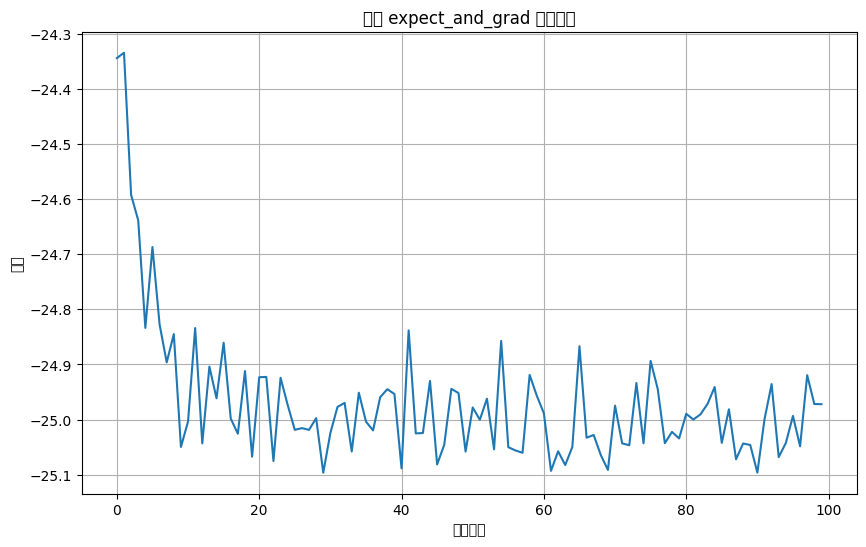

初始能量: -24.3445
最终能量: -24.9721


In [5]:
# 手动实现一个简单的优化循环来使用梯度
n_steps = 100
learning_rate = 0.05
energy_history = []

for i in range(n_steps):
    # 计算能量和梯度
    E, E_grad = vstate.expect_and_grad(H)
    energy_history.append(E.mean.real)
    
    # 更新参数
    new_pars = jax.tree_util.tree_map(
        lambda x, y: x - learning_rate * y, vstate.parameters, E_grad
    )
    vstate.parameters = new_pars

# 绘制能量随迭代的变化
plt.figure(figsize=(10, 6))
plt.plot(energy_history)
plt.xlabel('迭代次数')
plt.ylabel('能量')
plt.title('使用 expect_and_grad 优化能量')
plt.grid(True)
plt.show()

print(f"初始能量: {energy_history[0]:.4f}")
print(f"最终能量: {energy_history[-1]:.4f}")

## 性能优化

### 样本数量与精度

样本数量直接影响计算精度和效率：
- **更多样本**：降低统计误差，但增加计算时间
- **更少样本**：计算更快，但误差更大

最佳样本数取决于具体问题和所需精度。

样本数:   128, 能量: -19.9688 ± 0.3263
样本数:   512, 能量: -19.9765 ± 0.1987
样本数:  2048, 能量: -19.9258 ± 0.1012
样本数:  8192, 能量: -20.0156 ± 0.0494


/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20272 (\N{CJK UNIFIED IDEOGRAPH-4F30}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 

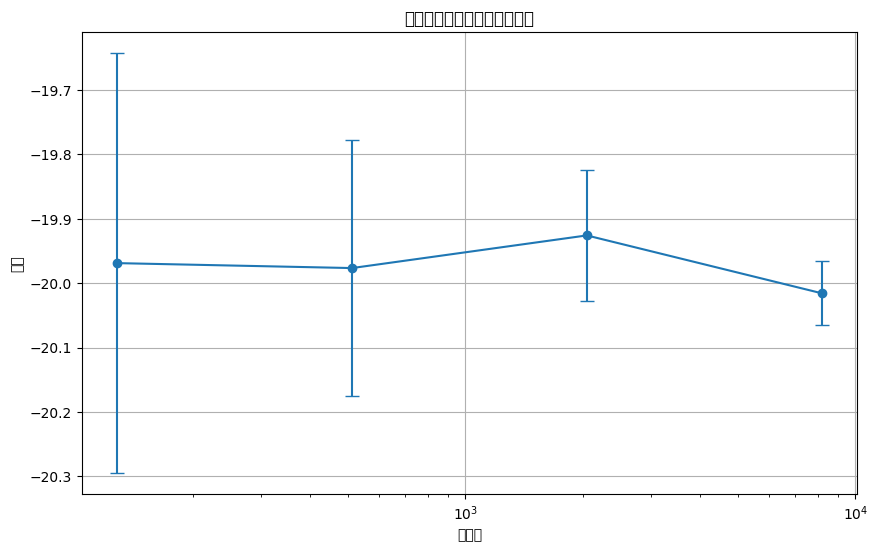

In [6]:
# 比较不同样本数对精度的影响
sample_sizes = [128, 512, 2048, 8192]
energies = []
errors = []

# 重置参数
vstate.init_parameters()

for n_samples in sample_sizes:
    vstate.n_samples = n_samples
    E, _ = vstate.expect_and_grad(H)
    energies.append(E.mean)
    errors.append(E.error_of_mean)
    print(f"样本数: {n_samples:5d}, 能量: {E.mean:.4f} ± {E.error_of_mean:.4f}")

# 绘制误差随样本数的变化
plt.figure(figsize=(10, 6))
plt.errorbar(sample_sizes, energies, yerr=errors, fmt='o-', capsize=5)
plt.xscale('log')
plt.xlabel('样本数')
plt.ylabel('能量')
plt.title('样本数对能量估计精度的影响')
plt.grid(True)
plt.show()

### 随机重配置(SR)预处理器

NetKet 提供了随机重配置(SR)预处理器，可以显著提高优化效率：

SR方法使用量子几何张量（费什信息矩阵）来预缩放梯度，使得优化更高效。

数学上，SR更新公式为：
$$\Delta\theta = -S^{-1} \nabla_\theta E$$
其中 $S_{ij} = \text{Re}\left[ \langle O_i^* O_j \rangle - \langle O_i^* \rangle \langle O_j \rangle \right]$ 是量子几何张量。

100%|██████████| 300/300 [00:04<00:00, 70.21it/s, Energy=-24.944 ± 0.052 [σ²=1.375, R̂=1.0331]]
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 33021 (\N{CJK UNIFIED IDEOGRAPH-80FD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22788 (\N{CJK UNIFIED IDEOGRAPH-5904}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/minicon

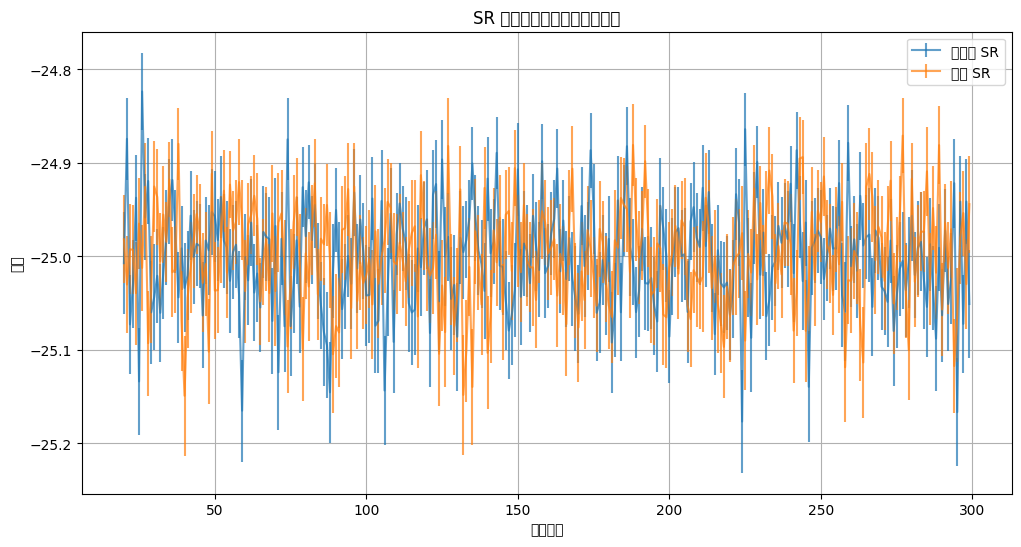

不使用 SR 的最终能量: -25.0508 ± 0.0582
使用 SR 的最终能量: -24.9441 ± 0.0518


In [7]:
# 比较使用和不使用 SR 预处理器的优化效果
from tqdm import tqdm

# 不使用 SR 的优化
vstate_no_sr = nk.vqs.MCState(sampler, MFModel(rngs=nnx.Rngs(0)), n_samples=512)
optimizer_no_sr = nk.optimizer.Sgd(learning_rate=0.05)
gs_no_sr = nk.driver.VMC(H, optimizer_no_sr, variational_state=vstate_no_sr)
log_no_sr = nk.logging.RuntimeLog()
gs_no_sr.run(n_iter=300, out=log_no_sr)

# 使用 SR 的优化
vstate_sr = nk.vqs.MCState(sampler, MFModel(rngs=nnx.Rngs(0)), n_samples=512)
optimizer_sr = nk.optimizer.Sgd(learning_rate=0.05)
gs_sr = nk.driver.VMC(
    H, 
    optimizer_sr, 
    variational_state=vstate_sr,
    preconditioner=nk.optimizer.SR(diag_shift=0.1)
)
log_sr = nk.logging.RuntimeLog()
gs_sr.run(n_iter=300, out=log_sr)

# 绘制比较结果
plt.figure(figsize=(12, 6))
plt.errorbar(
    log_no_sr.data["Energy"].iters[20:],
    log_no_sr.data["Energy"].Mean[20:],
    yerr=log_no_sr.data["Energy"].Sigma[20:],
    label="不使用 SR",
    alpha=0.7
)
plt.errorbar(
    log_sr.data["Energy"].iters[20:],
    log_sr.data["Energy"].Mean[20:],
    yerr=log_sr.data["Energy"].Sigma[20:],
    label="使用 SR",
    alpha=0.7
)
plt.xlabel('迭代次数')
plt.ylabel('能量')
plt.title('SR 预处理器对优化效率的影响')
plt.legend()
plt.grid(True)
plt.show()

print(f"不使用 SR 的最终能量: {log_no_sr.data['Energy'].Mean[-1]:.4f} ± {log_no_sr.data['Energy'].Sigma[-1]:.4f}")
print(f"使用 SR 的最终能量: {log_sr.data['Energy'].Mean[-1]:.4f} ± {log_sr.data['Energy'].Sigma[-1]:.4f}")

## 高级主题

### 复杂梯度计算

对于某些应用，可能需要计算更复杂的梯度，如：
- 高阶导数
- 约束优化
- 自适应学习率

NetKet 的灵活性允许这些高级应用。

In [8]:
# 演示如何访问和使用梯度信息进行高级分析

# 计算梯度和能量
E, E_grad = vstate.expect_and_grad(H)

# 计算梯度的范数
grad_norm = jnp.sqrt(sum(jnp.sum(g**2) for g in jax.tree_util.tree_leaves(E_grad)))
print(f"梯度范数: {grad_norm}")

# 计算每个参数对能量的贡献（一阶近似）
param_contributions = jax.tree_util.tree_map(lambda p, g: p * g, vstate.parameters, E_grad)
print(f"参数贡献: {param_contributions}")

# 分析梯度的统计性质
grad_values = jax.tree_util.tree_leaves(E_grad)[0]  # 获取梯度值
print(f"梯度统计:")
print(f"平均值: {jnp.mean(grad_values)}")
print(f"标准差: {jnp.std(grad_values)}")
print(f"最大值: {jnp.max(grad_values)}")
print(f"最小值: {jnp.min(grad_values)}")

梯度范数: 0.03815160572733786
参数贡献: {'log_phi_local': Array([2.39253908e-05], dtype=float64)}
梯度统计:
平均值: 0.03815160572733786
标准差: 0.0
最大值: 0.03815160572733786
最小值: 0.03815160572733786


## 总结

`expect_and_grad` 是 NetKet 中的核心函数，它结合了：

1. **期望值计算**：通过蒙特卡洛采样高效计算算符期望值
2. **自动微分**：利用 JAX 自动计算能量对变分参数的梯度
3. **统计分析**：提供误差估计、方差等统计量
4. **高效优化**：与各种优化器和预处理器兼容

### 关键要点

- 梯度计算基于协方差公式，利用了量子力学的特殊结构
- 自动微分使得复杂神经网络模型的梯度计算变得简单
- 统计误差分析对于评估结果质量至关重要
- SR预处理器可以显著提高优化效率

### 应用场景

- 基态能量计算
- 激发态计算
- 量子动力学模拟
- 量子机器学习

通过理解 `expect_and_grad` 的工作原理，您可以更有效地使用 NetKet 解决各种量子多体问题。